In [33]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import (
    OptimizerAgent,
    OptimizerAgentK2,
    OptimizerAgentK3,
    OptimizerAgentK4,
    OptimizerAgentKm,
)
from ant.centralised import P4

150
Generating market with 1 hop
Generating market with 2 hops
Generating market with 3 hops
Generating market with 4 hops
Generating market with all hops


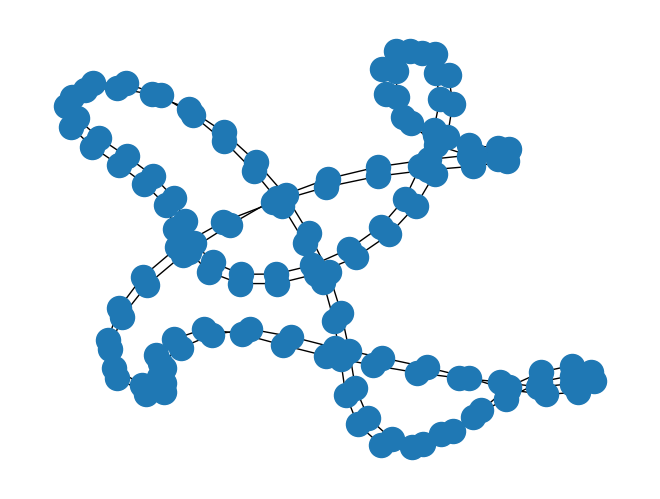

In [ ]:
# Demo experiment
market_size = 150
seed = 73
# G = nx.gnp_random_graph(market_size, 0.04, seed=seed)
G = nx.circular_ladder_graph(int(market_size / 2))
if not nx.is_connected(G):
    print("G is not connected")
print(len(G))
nx.draw(G)
# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
proportional_market: Market = Market(
    market_size, graph=G, seed=seed, agent_type=ProportionalAgent
)
# edge_market: Market = Market(
#     market_size, graph=G, seed=seed, agent_type=RecirpocateAgent
# )
# maxfinder_market: Market = Market(market_size, graph=G, seed=seed, agent_type=MaxFinder)

equal_market: Market = Market(
    market_size, graph=G, seed=seed, agent_type=EqualDivisionAgent
)
print("Generating market with 1 hop")
optimizer_market_k1: Market = Market(
    market_size, graph=G, seed=seed, agent_type=OptimizerAgent
)
print("Generating market with 2 hops")
optimizer_market_k2: Market = Market(
    market_size, graph=G, seed=seed, agent_type=OptimizerAgent, k=2
)
print("Generating market with 3 hops")
optimizer_market_k3: Market = Market(
    market_size, graph=G, seed=seed, agent_type=OptimizerAgent, k=3
)
print("Generating market with 4 hops")
optimizer_market_k4: Market = Market(
    market_size, graph=G, seed=seed, agent_type=OptimizerAgent, k=4
)
# print("Generating market with all hops")
# optimizer_market_all: Market = Market(
#     market_size, graph=G, seed=seed, agent_type=OptimizerAgent, k=75
# )

In [35]:
allocation_matrix, utility = computed_equilibrium = P4(proportional_market)

In [40]:
simulation_length = 50
proportional_market.set_market_equilibrium(allocation_matrix, utility)
equal_market.set_market_equilibrium(allocation_matrix, utility)
# edge_market.set_market_equilibrium(allocation_matrix, utility)
# maxfinder_market.set_market_equilibrium(allocation_matrix, utility)
optimizer_market_k1.set_market_equilibrium(allocation_matrix, utility)
optimizer_market_k2.set_market_equilibrium(allocation_matrix, utility)
optimizer_market_k3.set_market_equilibrium(allocation_matrix, utility)
optimizer_market_k4.set_market_equilibrium(allocation_matrix, utility)
optimizer_market_all.set_market_equilibrium(allocation_matrix, utility)

simulated_state_proportional = proportional_market.simulate(simulation_length)
simulated_equal_market = equal_market.simulate(simulation_length)
# simulated_state_edge = edge_market.simulate(simulation_length)
# simulated_state_maxfinder = maxfinder_market.simulate(simulation_length)
simulated_optimizer_k1 = optimizer_market_k1.simulate(simulation_length)
simulated_optimizer_k2 = optimizer_market_k2.simulate(simulation_length)
simulated_optimizer_k3 = optimizer_market_k3.simulate(simulation_length)
simulated_optimizer_k4 = optimizer_market_k4.simulate(simulation_length)
# simulated_optimizer_km = optimizer_market_all.simulate(simulation_length, use_average_in_market_loss=False)

Solver crashed. t=0, k=1
Solver crashed. t=1, k=1
Solver crashed. t=2, k=1
Solver crashed. t=3, k=1
Solver crashed. t=4, k=1
Solver crashed. t=5, k=1
Solver crashed. t=6, k=1
Solver crashed. t=7, k=1
Solver crashed. t=8, k=1
Solver crashed. t=9, k=1
Solver crashed. t=10, k=1
Solver crashed. t=11, k=1
Solver crashed. t=12, k=1
Solver crashed. t=13, k=1
Solver crashed. t=14, k=1
Solver crashed. t=15, k=1
Solver crashed. t=16, k=1
Solver crashed. t=17, k=1
Solver crashed. t=18, k=1
Solver crashed. t=19, k=1
Solver crashed. t=20, k=1
Solver crashed. t=21, k=1
Solver crashed. t=22, k=1
Solver crashed. t=23, k=1
Solver crashed. t=24, k=1
Solver crashed. t=25, k=1
Solver crashed. t=26, k=1
Solver crashed. t=27, k=1
Solver crashed. t=28, k=1
Solver crashed. t=29, k=1
Solver crashed. t=30, k=1
Solver crashed. t=31, k=1
Solver crashed. t=32, k=1
Solver crashed. t=33, k=1
Solver crashed. t=34, k=1
Solver crashed. t=35, k=1
Solver crashed. t=36, k=1
Solver crashed. t=37, k=1
Solver crashed. t=38, 

In [37]:
# print(simulated_optimizer_k1)

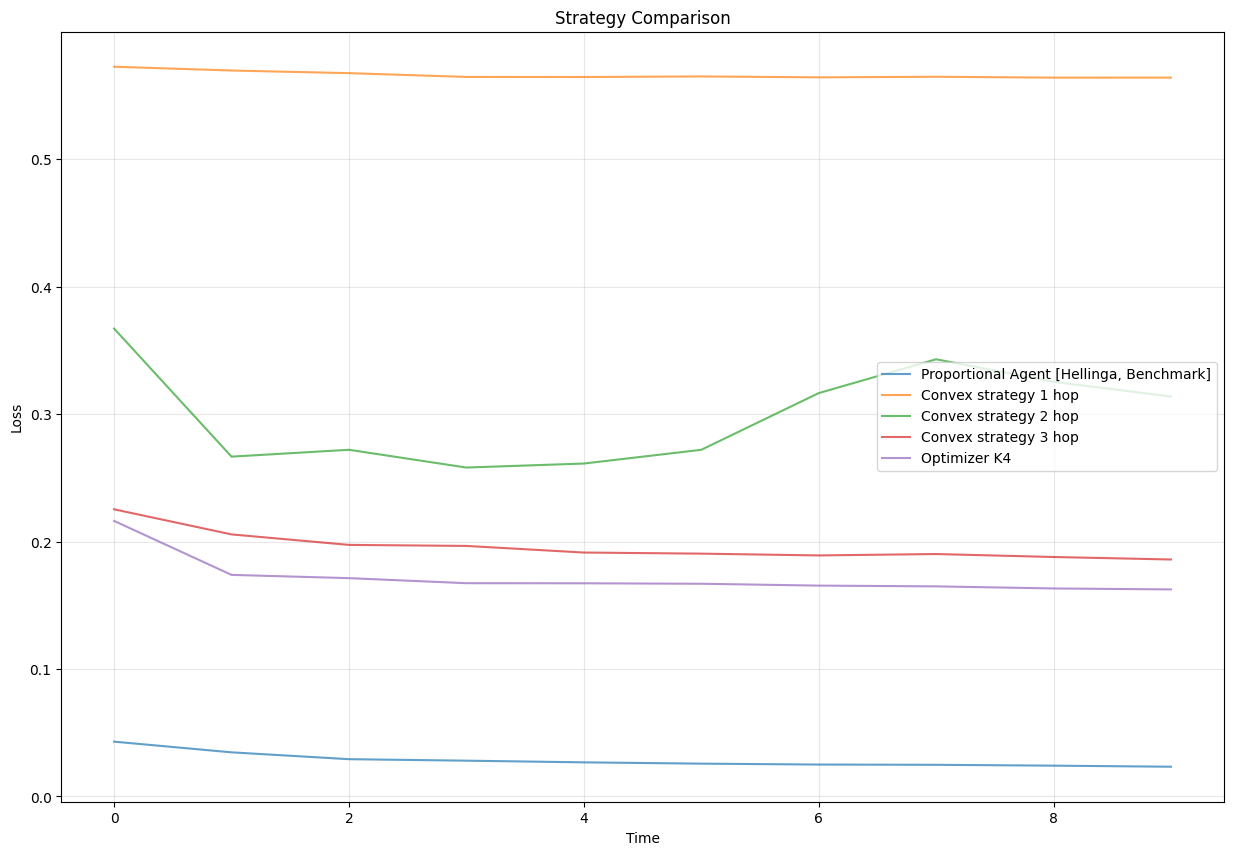

In [41]:
window = (0, 10)
time_steps = np.arange(window[0], window[1])

plt.figure(figsize=(15, 10))
plt.plot(
    time_steps,
    simulated_state_proportional[window[0] : window[1]],
    label="Proportional Agent [Hellinga, Benchmark]",
    alpha=0.7,
)
# plt.plot(
#     time_steps,
#     simulated_state_edge[training_period:],
#     label="Edge Agent",
#     alpha=0.7,
# )

# plt.plot(
#     time_steps,
#     simulated_state_maxfinder[training_period:],
#     label="MaxFinder Agent",
#     alpha=0.7,
# )

# plt.plot(
#     time_steps,
#     simulated_equal_market[window[0]:window[1]],
#     label="Equal Division Market [Benchmark]",
#     alpha=0.7,
# )

plt.plot(
    time_steps,
    simulated_optimizer_k1[window[0] : window[1]],
    label="Convex strategy 1 hop",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_optimizer_k2[window[0] : window[1]],
    label="Convex strategy 2 hop",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_optimizer_k3[window[0] : window[1]],
    label="Convex strategy 3 hop",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_optimizer_k4[window[0]:window[1]],
    label="Optimizer K4",
    alpha=0.7,
)

# plt.plot(
#     time_steps,
#     simulated_optimizer_km[window[0]:window[1]],
#     label="Optimizer Km",
#     alpha=0.7,
# )

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()